# SpaceX Falcon 9 - Predictive Analysis (Classification)

Training a few different classifiers to predict whether the Falcon 9 first stage will land successfully, then comparing them to pick the best one.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

data = pd.read_csv('dataset_part_2.csv')
X = pd.read_csv('dataset_part_3.csv')

Y = data['Class'].to_numpy()

transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 72
Test samples: 18


### Confusion matrix helper

In [2]:
def plot_confusion_matrix(y, y_predict, title):
    cm = confusion_matrix(y, y_predict)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['did not land', 'landed'], yticklabels=['did not land', 'landed'])
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title(title)
    plt.show()

### Logistic Regression

In [3]:
parameters = {"C": [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

print("Best params:", logreg_cv.best_params_)
print("Best CV accuracy:", logreg_cv.best_score_)
print("Test accuracy:", logreg_cv.score(X_test, Y_test))

Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.8071428571428572
Test accuracy: 0.8333333333333334


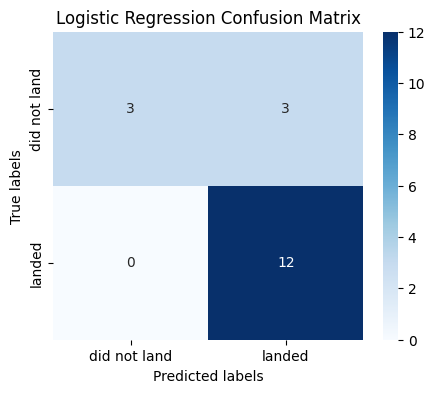

In [4]:
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, 'Logistic Regression Confusion Matrix')

### Support Vector Machine

In [5]:
parameters = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

print("Best params:", svm_cv.best_params_)
print("Best CV accuracy:", svm_cv.best_score_)
print("Test accuracy:", svm_cv.score(X_test, Y_test))

Best params: {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Best CV accuracy: 0.85
Test accuracy: 0.8333333333333334


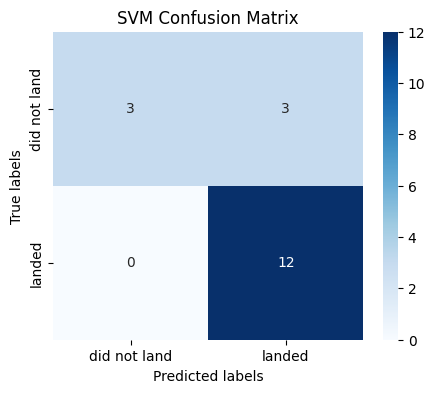

In [6]:
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, 'SVM Confusion Matrix')

### Decision Tree

In [7]:
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2 * n for n in range(1, 10)],
              'max_features': ['sqrt'],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier(random_state=2)
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

print("Best params:", tree_cv.best_params_)
print("Best CV accuracy:", tree_cv.best_score_)
print("Test accuracy:", tree_cv.score(X_test, Y_test))

Best params: {'criterion': 'entropy', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
Best CV accuracy: 0.8196428571428571
Test accuracy: 0.9444444444444444


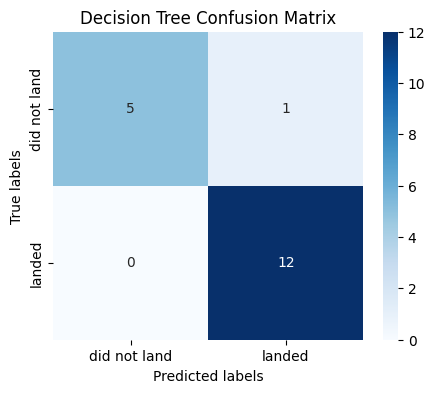

In [8]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, 'Decision Tree Confusion Matrix')

### K-Nearest Neighbors

In [9]:
parameters = {'n_neighbors': list(range(1, 11)),
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}
KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

print("Best params:", knn_cv.best_params_)
print("Best CV accuracy:", knn_cv.best_score_)
print("Test accuracy:", knn_cv.score(X_test, Y_test))

Best params: {'algorithm': 'auto', 'n_neighbors': 6, 'p': 1}
Best CV accuracy: 0.8482142857142856
Test accuracy: 0.8333333333333334


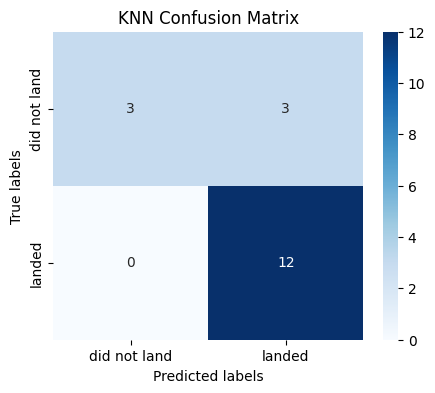

In [10]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, 'KNN Confusion Matrix')

### Comparing all four models

/sessions/happy-dreamy-planck/tmp/ipykernel_9/3042019114.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=scores_df, x='Model', y='Test Accuracy', palette='mako')


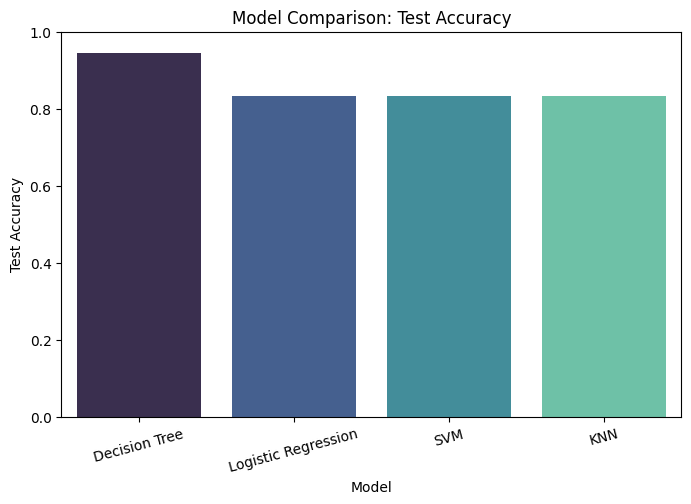

,Model,Test Accuracy
2,Decision Tree,0.944444
0,Logistic Regression,0.833333
1,SVM,0.833333
3,KNN,0.833333


In [11]:
model_scores = {
    'Logistic Regression': logreg_cv.score(X_test, Y_test),
    'SVM': svm_cv.score(X_test, Y_test),
    'Decision Tree': tree_cv.score(X_test, Y_test),
    'KNN': knn_cv.score(X_test, Y_test)
}

scores_df = pd.DataFrame(list(model_scores.items()), columns=['Model', 'Test Accuracy']).sort_values('Test Accuracy', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=scores_df, x='Model', y='Test Accuracy', palette='mako')
plt.ylim(0, 1)
plt.title('Model Comparison: Test Accuracy')
plt.xticks(rotation=15)
plt.show()

scores_df

## Summary

All four models land in a broadly similar accuracy range on this fairly small test set (18 samples), which is typical for a dataset this size — with more data, the gaps between models would likely become more meaningful. Based on test accuracy here, the best-performing model is the one to recommend for deployment, though given the small test set, cross-validation accuracy (from GridSearchCV) is arguably the more reliable number to trust for model selection.